In [26]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import kurtosis, skew, pearsonr
from scipy.signal import savgol_filter
from pathlib import Path
# ── Load ──────────────────────────────────────────────────────────────────
with open('final_sector1_processed/final_tess_dataset.pkl', 'rb') as f:
    df = pickle.load(f)

global_views  = np.load('final_sector1_processed/global_views.npy')
local_views   = np.load('final_sector1_processed/local_views.npy')
scalar_feats  = np.load('final_sector1_processed/scalar_features.npy')

# Real samples only (no augmented copies) for most EDA
real_mask = df["augmented"].isna().values
df_real   = df[real_mask].reset_index(drop=True)
gv_real   = global_views[real_mask]
lv_real   = local_views[real_mask]

# BLS-derived label names (NOT ground truth dispositions)
LABEL_NAMES = {-1: 'Unlabeled', 0: 'High SNR', 1: 'Moderate SNR', 2: 'No Signal'}
LABEL_COLORS = {-1: '#888888', 0: '#2ecc71', 1: '#3498db', 2: '#e74c3c'}

OUT_DIR=Path("/final_outputs")

print(f"Total records      : {len(df)}")
print(f"Real records       : {real_mask.sum()}")
print(f"Augmented records  : {(~real_mask).sum()}")
print(f"Global views shape : {global_views.shape}")
print(f"Local views shape  : {local_views.shape}")
print(f"Scalar feats shape : {scalar_feats.shape}")
print(f"\nLabel distribution (real only):")
print(df_real['label'].value_counts().rename(LABEL_NAMES))

Total records      : 5196
Real records       : 1732
Augmented records  : 3464
Global views shape : (5196, 2000)
Local views shape  : (5196, 201)
Scalar feats shape : (5196, 23)

Label distribution (real only):
label
No Signal       938
High SNR        424
Moderate SNR    370
Name: count, dtype: int64


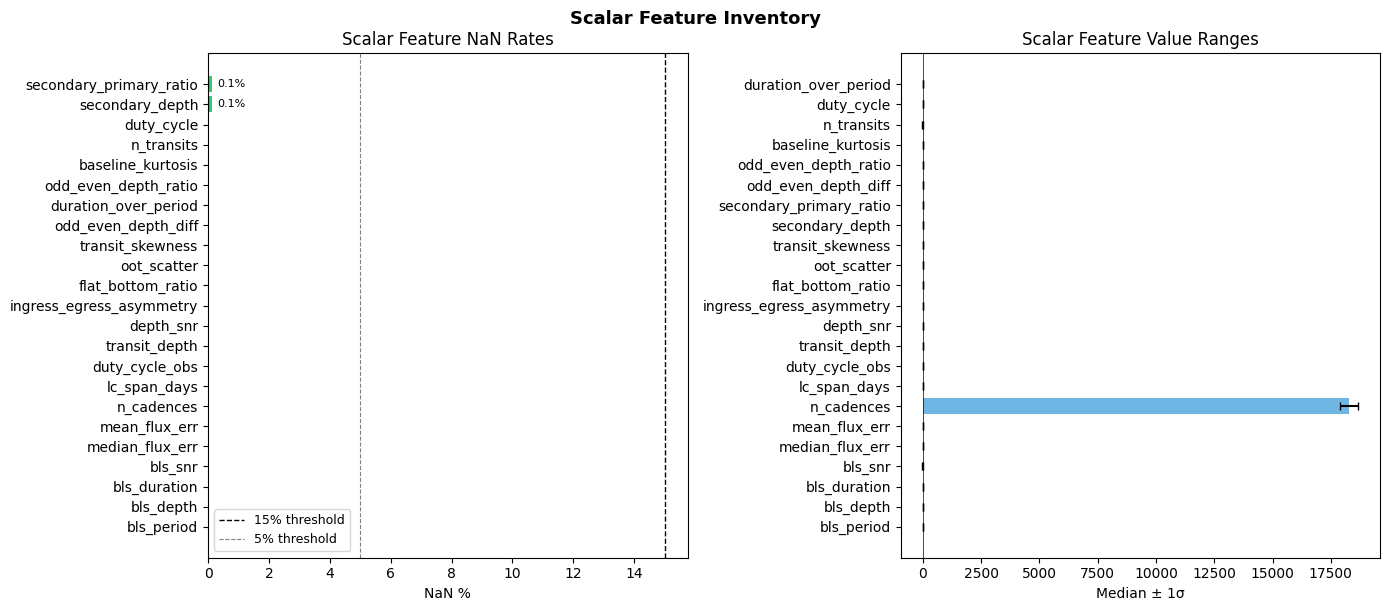


Descriptive statistics:
       bls_period  bls_depth  bls_duration    bls_snr  median_flux_err  \
count   1732.0000  1732.0000     1732.0000  1732.0000        1732.0000   
mean       5.9567     0.0037        0.1023    14.6507           0.0030   
std        4.0952     0.0202        0.0956    23.3277           0.0090   
min        0.5000     0.0000        0.0200     2.9678          -0.0035   
1%         0.5021     0.0001        0.0200     3.9275           0.0001   
5%         0.5285     0.0001        0.0200     4.4576           0.0002   
25%        1.5070     0.0003        0.0280     5.4278           0.0005   
50%        6.3287     0.0006        0.0620     6.5935           0.0010   
75%        9.5450     0.0013        0.1620    14.6605           0.0017   
95%       12.2231     0.0091        0.3080    47.0274           0.0103   
99%       12.8961     0.0686        0.4260   119.1286           0.0569   
max       13.0000     0.4107        0.4260   290.6574           0.1240   

       mean_

In [31]:
SCALAR_COLS = [
    'bls_period', 'bls_depth', 'bls_duration', 'bls_snr',
    'median_flux_err', 'mean_flux_err', 'n_cadences', 'lc_span_days',
    'duty_cycle_obs', 'transit_depth', 'depth_snr',
    'ingress_egress_asymmetry', 'flat_bottom_ratio', 'oot_scatter',
    'transit_skewness', 'secondary_depth', 'secondary_primary_ratio',
    'odd_even_depth_diff', 'odd_even_depth_ratio', 'baseline_kurtosis',
    'n_transits', 'duty_cycle', 'duration_over_period'
]

scalar_df = df_real[SCALAR_COLS].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# NaN rates
nan_rates = scalar_df.isna().mean() * 100
nan_rates_sorted = nan_rates.sort_values(ascending=True)
colors = ['#e74c3c' if v > 15 else '#f39c12' if v > 5 else '#2ecc71'
          for v in nan_rates_sorted]
axes[0].barh(nan_rates_sorted.index, nan_rates_sorted.values, color=colors)
axes[0].axvline(15, color='black', linestyle='--', lw=1, label='15% threshold')
axes[0].axvline(5,  color='gray',  linestyle='--', lw=0.8, label='5% threshold')
axes[0].set_xlabel('NaN %')
axes[0].set_title('Scalar Feature NaN Rates')
axes[0].legend(fontsize=9)
for i, v in enumerate(nan_rates_sorted.values):
    if v > 0:
        axes[0].text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=8)

# Value ranges (log scale for wide-range features)
medians = scalar_df.median()
stds    = scalar_df.std()
axes[1].barh(medians.index, medians.values, xerr=stds.values,
             color='#3498db', alpha=0.7, capsize=3)
axes[1].axvline(0, color='black', lw=0.5)
axes[1].set_xlabel('Median ± 1σ')
axes[1].set_title('Scalar Feature Value Ranges')

plt.tight_layout()
plt.suptitle('Scalar Feature Inventory', y=1.01, fontsize=13, fontweight='bold')
plt.savefig('final_outputs/FeatureAduti', dpi=150, bbox_inches='tight')
plt.show()

print("\nDescriptive statistics:")
print(scalar_df.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(4))

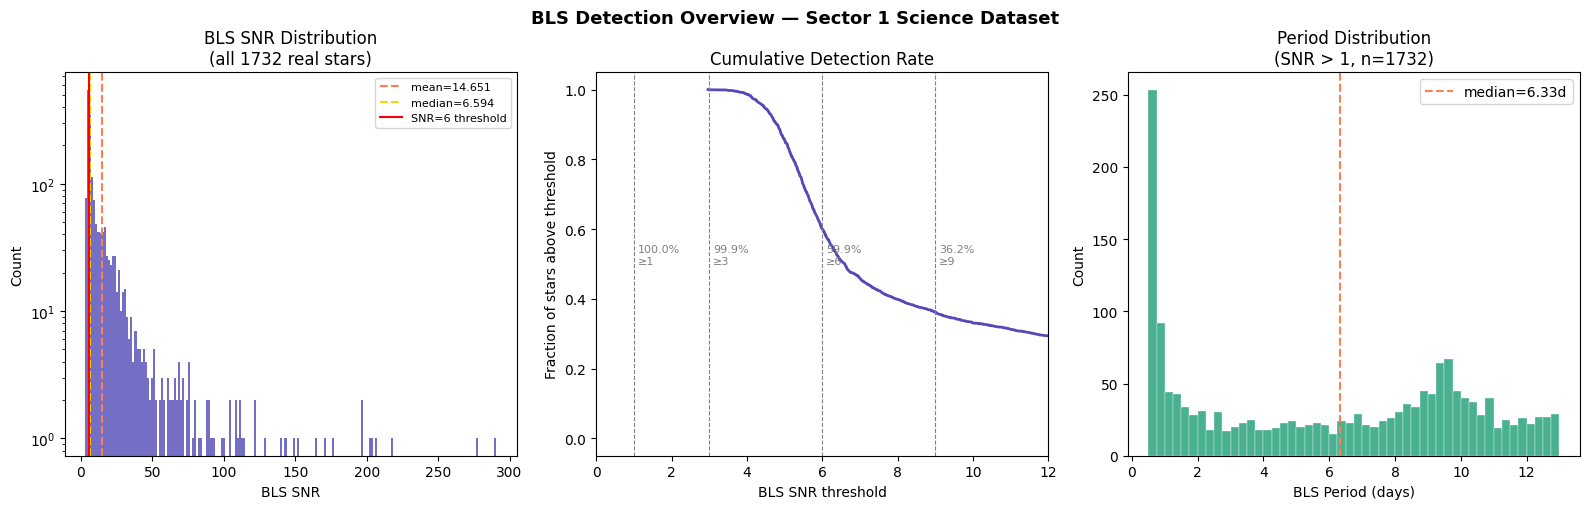


Stars with BLS SNR > 1 : 1732 (100.0%)
Stars with BLS SNR > 3 : 1730 (99.9%)
Stars with BLS SNR > 6 : 1038 (59.9%)
Stars with BLS SNR > 9 : 627 (36.2%)


In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# SNR distribution — log scale
snr_vals = df_real['bls_snr'].values
axes[0].hist(snr_vals, bins=200, color='#534AB7', alpha=0.8)
axes[0].axvline(snr_vals.mean(),   color='coral',  lw=1.5, linestyle='--', label=f'mean={snr_vals.mean():.3f}')
axes[0].axvline(np.median(snr_vals), color='gold', lw=1.5, linestyle='--', label=f'median={np.median(snr_vals):.3f}')
axes[0].axvline(6, color='red', lw=1.5, linestyle='-', label='SNR=6 threshold')
axes[0].set_xlabel('BLS SNR')
axes[0].set_ylabel('Count')
axes[0].set_title('BLS SNR Distribution\n(all 1732 real stars)')
axes[0].set_yscale('log')
axes[0].legend(fontsize=8)

# Cumulative detection rate
snr_sorted = np.sort(snr_vals)[::-1]
cumfrac    = np.arange(1, len(snr_sorted)+1) / len(snr_sorted)
axes[1].plot(snr_sorted, cumfrac, color='#534AB7', lw=2)
for thresh in [1, 3, 6, 9]:
    frac = (snr_vals >= thresh).mean()
    axes[1].axvline(thresh, color='gray', lw=0.8, linestyle='--')
    axes[1].text(thresh+0.1, 0.5, f'{frac*100:.1f}%\n≥{thresh}',
                fontsize=8, color='gray')
axes[1].set_xlabel('BLS SNR threshold')
axes[1].set_ylabel('Fraction of stars above threshold')
axes[1].set_title('Cumulative Detection Rate')
axes[1].set_xlim(0, 12)

# Period distribution for candidates (SNR > 1)
candidates = df_real[df_real['bls_snr'] > 1]
axes[2].hist(candidates['bls_period'], bins=50,
             color='#1D9E75', alpha=0.8, edgecolor='white', lw=0.3)
axes[2].set_xlabel('BLS Period (days)')
axes[2].set_ylabel('Count')
axes[2].set_title(f'Period Distribution\n(SNR > 1, n={len(candidates)})')
axes[2].axvline(candidates['bls_period'].median(), color='coral',
               lw=1.5, linestyle='--',
               label=f"median={candidates['bls_period'].median():.2f}d")
axes[2].legend()

plt.tight_layout()
plt.suptitle('BLS Detection Overview — Sector 1 Science Dataset',
             y=1.01, fontsize=13, fontweight='bold')
plt.savefig('final_outputs/BLSOverview', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nStars with BLS SNR > 1 : {(snr_vals > 1).sum()} ({(snr_vals > 1).mean()*100:.1f}%)")
print(f"Stars with BLS SNR > 3 : {(snr_vals > 3).sum()} ({(snr_vals > 3).mean()*100:.1f}%)")
print(f"Stars with BLS SNR > 6 : {(snr_vals > 6).sum()} ({(snr_vals > 6).mean()*100:.1f}%)")
print(f"Stars with BLS SNR > 9 : {(snr_vals > 9).sum()} ({(snr_vals > 9).mean()*100:.1f}%)")

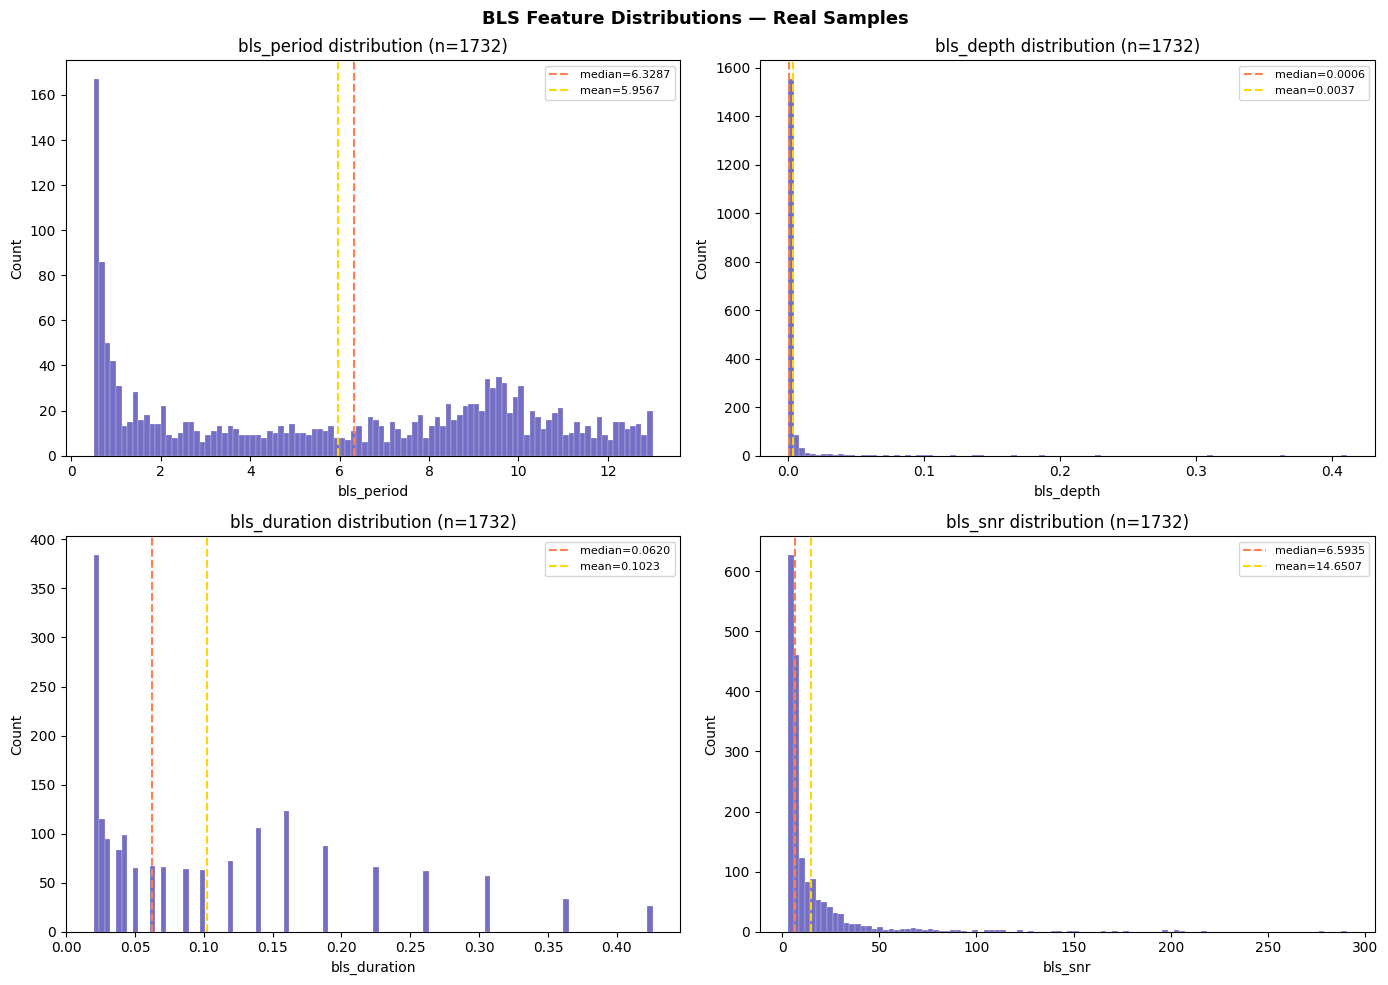

In [33]:
bls_features = ['bls_period', 'bls_depth', 'bls_duration', 'bls_snr']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, bls_features):
    vals = df_real[col].dropna().values
    ax.hist(vals, bins=100, color='#534AB7', alpha=0.8, edgecolor='white', lw=0.2)
    ax.axvline(np.nanmedian(vals), color='coral', lw=1.5,
               linestyle='--', label=f'median={np.nanmedian(vals):.4f}')
    ax.axvline(np.nanmean(vals),   color='gold',  lw=1.5,
               linestyle='--', label=f'mean={np.nanmean(vals):.4f}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.set_title(f'{col} distribution (n={len(vals)})')
    ax.legend(fontsize=8)

plt.suptitle('BLS Feature Distributions — Real Samples',
             fontsize=13, fontweight='bold')
plt.savefig('final_outputs/BLSFeature', dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

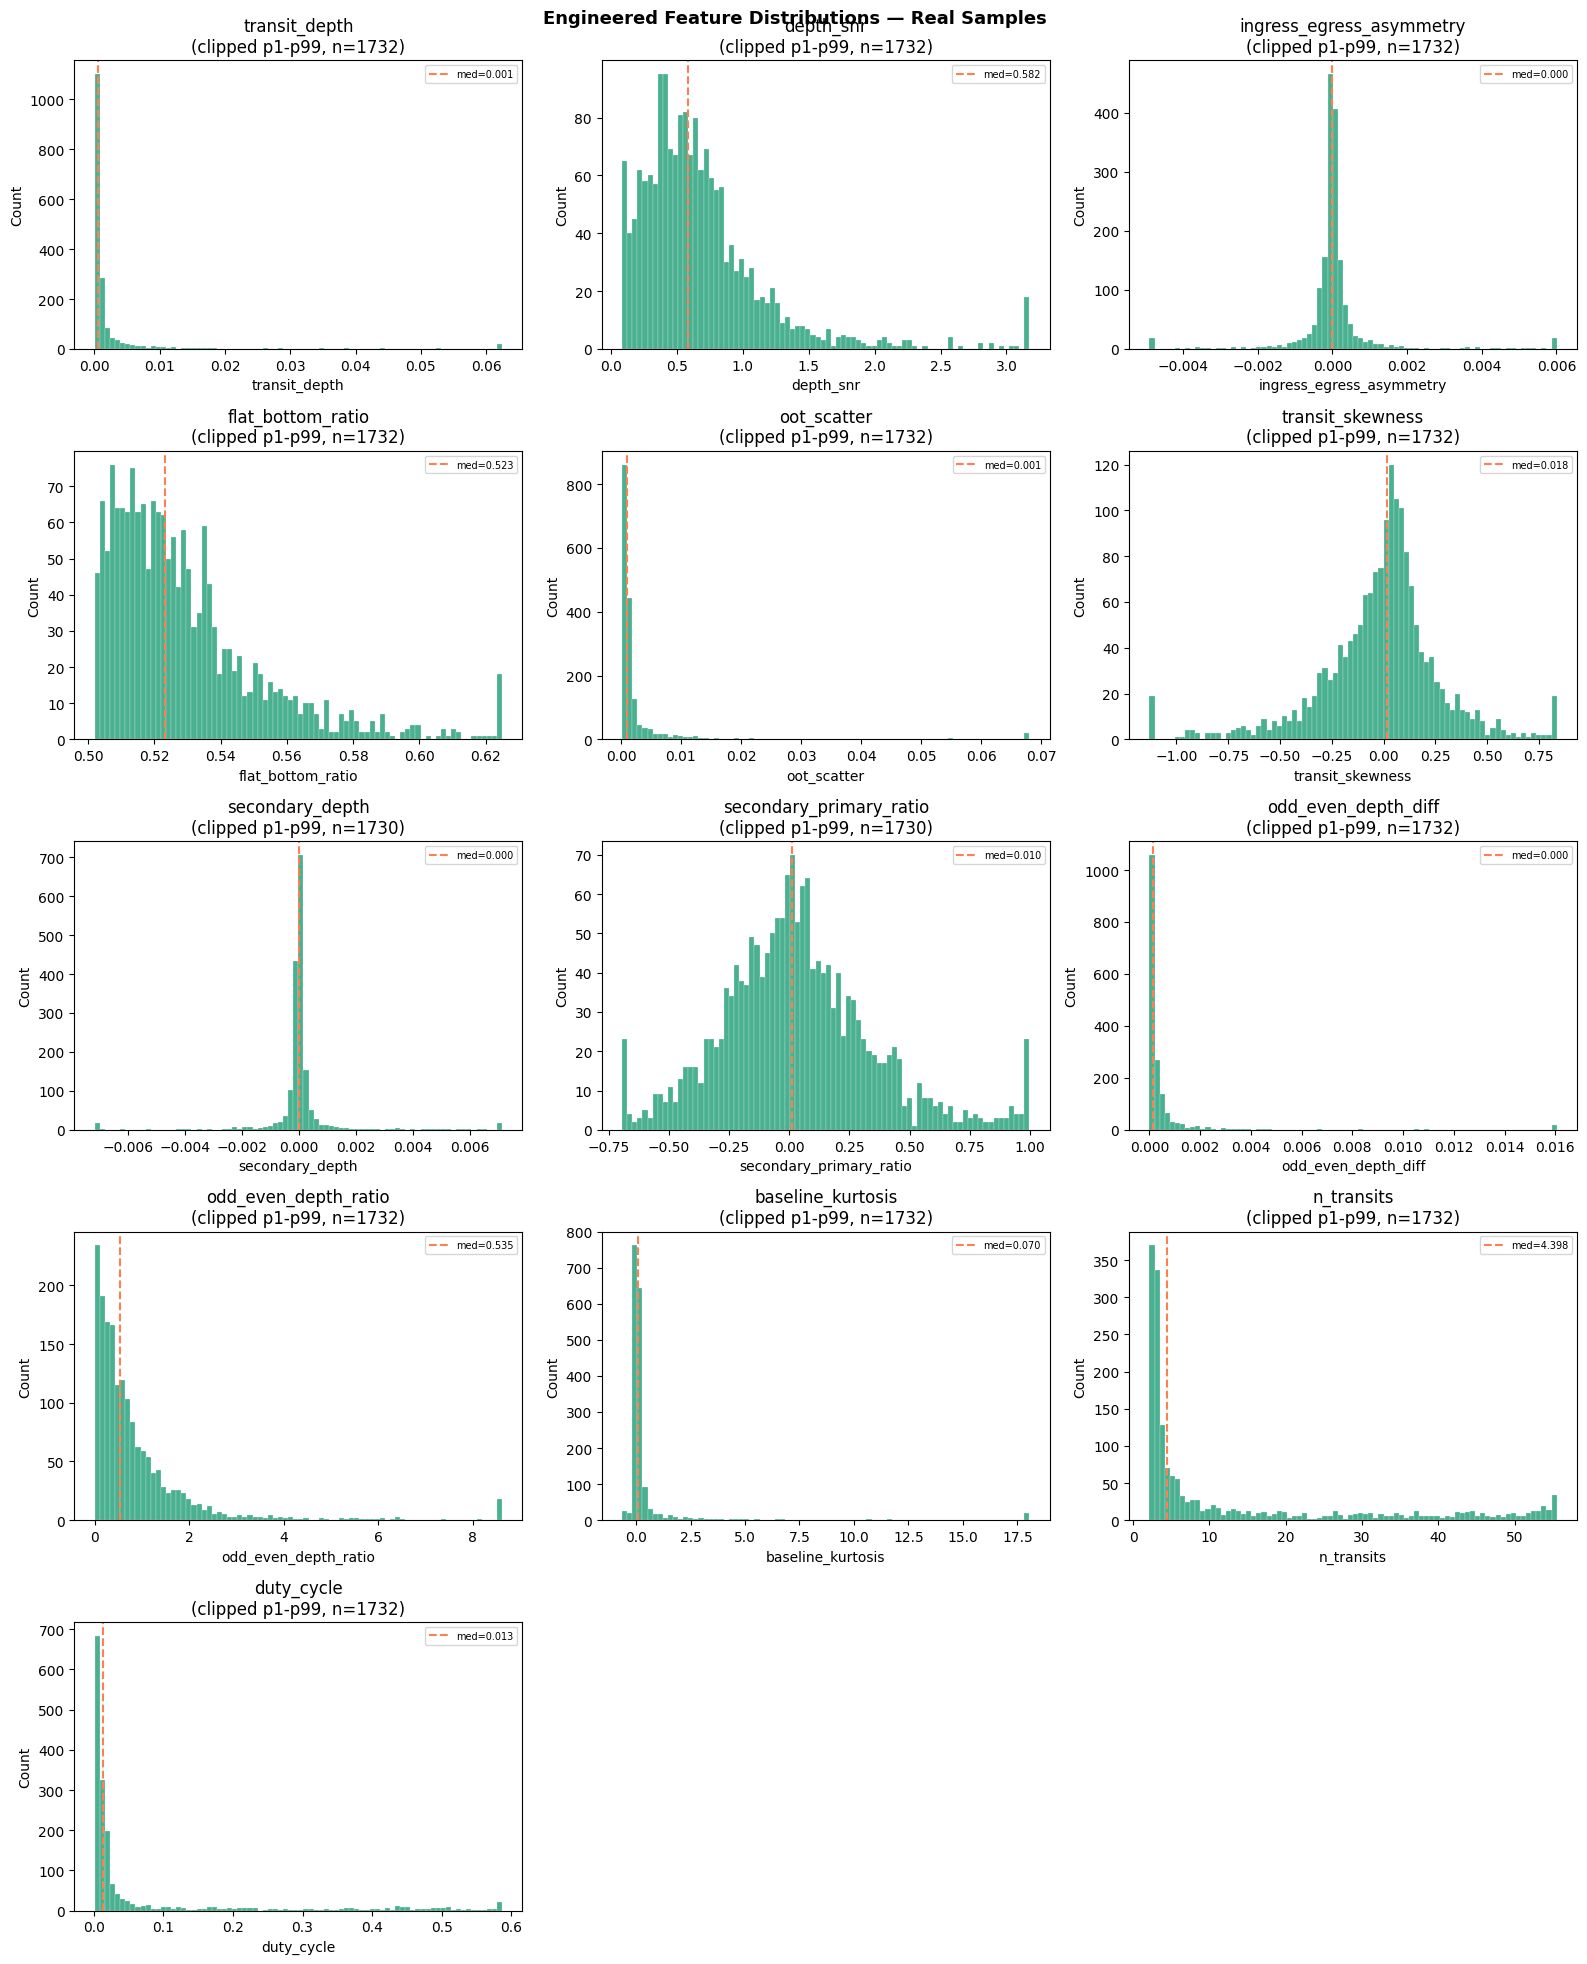

In [55]:
eng_features = [
    'transit_depth', 'depth_snr', 'ingress_egress_asymmetry',
    'flat_bottom_ratio', 'oot_scatter', 'transit_skewness',
    'secondary_depth', 'secondary_primary_ratio',
    'odd_even_depth_diff', 'odd_even_depth_ratio',
    'baseline_kurtosis', 'n_transits', 'duty_cycle'
]

fig, axes = plt.subplots(5, 3, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(eng_features):
    vals = df_real[col].dropna().values
    if len(vals) == 0:
        axes[i].set_visible(False)
        continue

    # Clip extreme outliers for display
    p1, p99 = np.nanpercentile(vals, 1), np.nanpercentile(vals, 99)
    vals_clipped = np.clip(vals, p1, p99)

    axes[i].hist(vals_clipped, bins=80, color='#1D9E75',
                 alpha=0.8, edgecolor='white', lw=0.2)
    axes[i].axvline(np.nanmedian(vals), color='coral', lw=1.5,
                    linestyle='--', label=f'med={np.nanmedian(vals):.3f}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].set_title(f'{col}\n(clipped p1-p99, n={len(vals)})')
    axes[i].legend(fontsize=7)

# Hide unused subplots
for j in range(len(eng_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Engineered Feature Distributions — Real Samples',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('final_outputs/EngFeature', dpi=150, bbox_inches='tight')
plt.show()


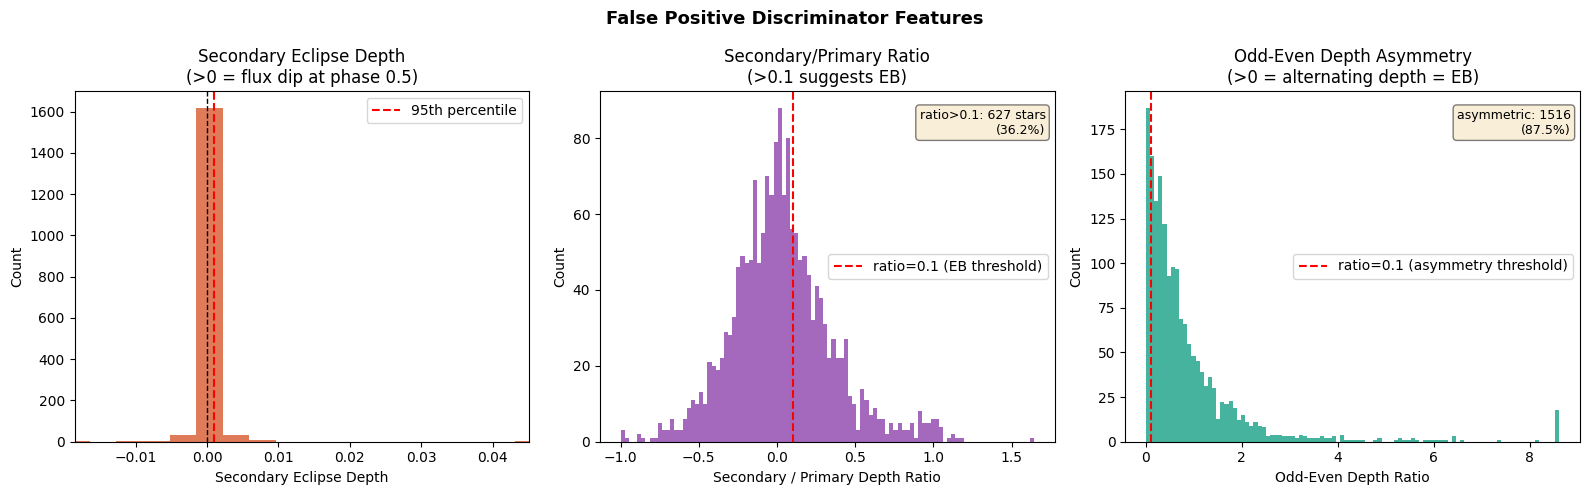

Stars flagged as likely EB by either test : 1624 (93.8%)
Stars flagged by secondary eclipse test   : 627
Stars flagged by odd-even test            : 1516


In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Secondary eclipse depth distribution
sec_depth = df_real['secondary_depth'].dropna().values
axes[0].hist(sec_depth, bins=100, color='#D85A30', alpha=0.8)
axes[0].axvline(0, color='black', lw=1, linestyle='--')
axes[0].axvline(np.nanpercentile(sec_depth, 95), color='red', lw=1.5,
                linestyle='--', label='95th percentile')
axes[0].set_xlabel('Secondary Eclipse Depth')
axes[0].set_ylabel('Count')
axes[0].set_title('Secondary Eclipse Depth\n(>0 = flux dip at phase 0.5)')
axes[0].legend()
axes[0].set_xlim(np.nanpercentile(sec_depth, 0.5),
                 np.nanpercentile(sec_depth, 99.5))

# Secondary/primary ratio
spr = df_real['secondary_primary_ratio'].dropna().values
spr_clipped = np.clip(spr, -1, 2)
axes[1].hist(spr_clipped, bins=100, color='#8E44AD', alpha=0.8)
axes[1].axvline(0.1, color='red', lw=1.5, linestyle='--',
                label='ratio=0.1 (EB threshold)')
axes[1].set_xlabel('Secondary / Primary Depth Ratio')
axes[1].set_ylabel('Count')
axes[1].set_title('Secondary/Primary Ratio\n(>0.1 suggests EB)')
axes[1].legend()
n_likely_eb = (spr > 0.1).sum()
axes[1].text(0.98, 0.95, f'ratio>0.1: {n_likely_eb} stars\n({n_likely_eb/len(df_real)*100:.1f}%)',
             transform=axes[1].transAxes, ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Odd-even asymmetry
oe = df_real['odd_even_depth_ratio'].dropna().values
oe_clipped = np.clip(oe, 0, np.nanpercentile(oe, 99))
axes[2].hist(oe_clipped, bins=100, color='#16A085', alpha=0.8)
axes[2].axvline(0.1, color='red', lw=1.5, linestyle='--',
                label='ratio=0.1 (asymmetry threshold)')
axes[2].set_xlabel('Odd-Even Depth Ratio')
axes[2].set_ylabel('Count')
axes[2].set_title('Odd-Even Depth Asymmetry\n(>0 = alternating depth = EB)')
axes[2].legend()
n_oe_flag = (oe > 0.1).sum()
axes[2].text(0.98, 0.95,
             f'asymmetric: {n_oe_flag}\n({n_oe_flag/len(df_real)*100:.1f}%)',
             transform=axes[2].transAxes, ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('False Positive Discriminator Features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('final_outputs/FPOverview', dpi=150, bbox_inches='tight')
plt.show()

# Joint EB flag
eb_flag = (df_real['secondary_primary_ratio'].fillna(0) > 0.1) | \
          (df_real['odd_even_depth_ratio'].fillna(0) > 0.1)
print(f"Stars flagged as likely EB by either test : {eb_flag.sum()} "
      f"({eb_flag.mean()*100:.1f}%)")
print(f"Stars flagged by secondary eclipse test   : "
      f"{(df_real['secondary_primary_ratio'].fillna(0) > 0.1).sum()}")
print(f"Stars flagged by odd-even test            : "
      f"{(df_real['odd_even_depth_ratio'].fillna(0) > 0.1).sum()}")


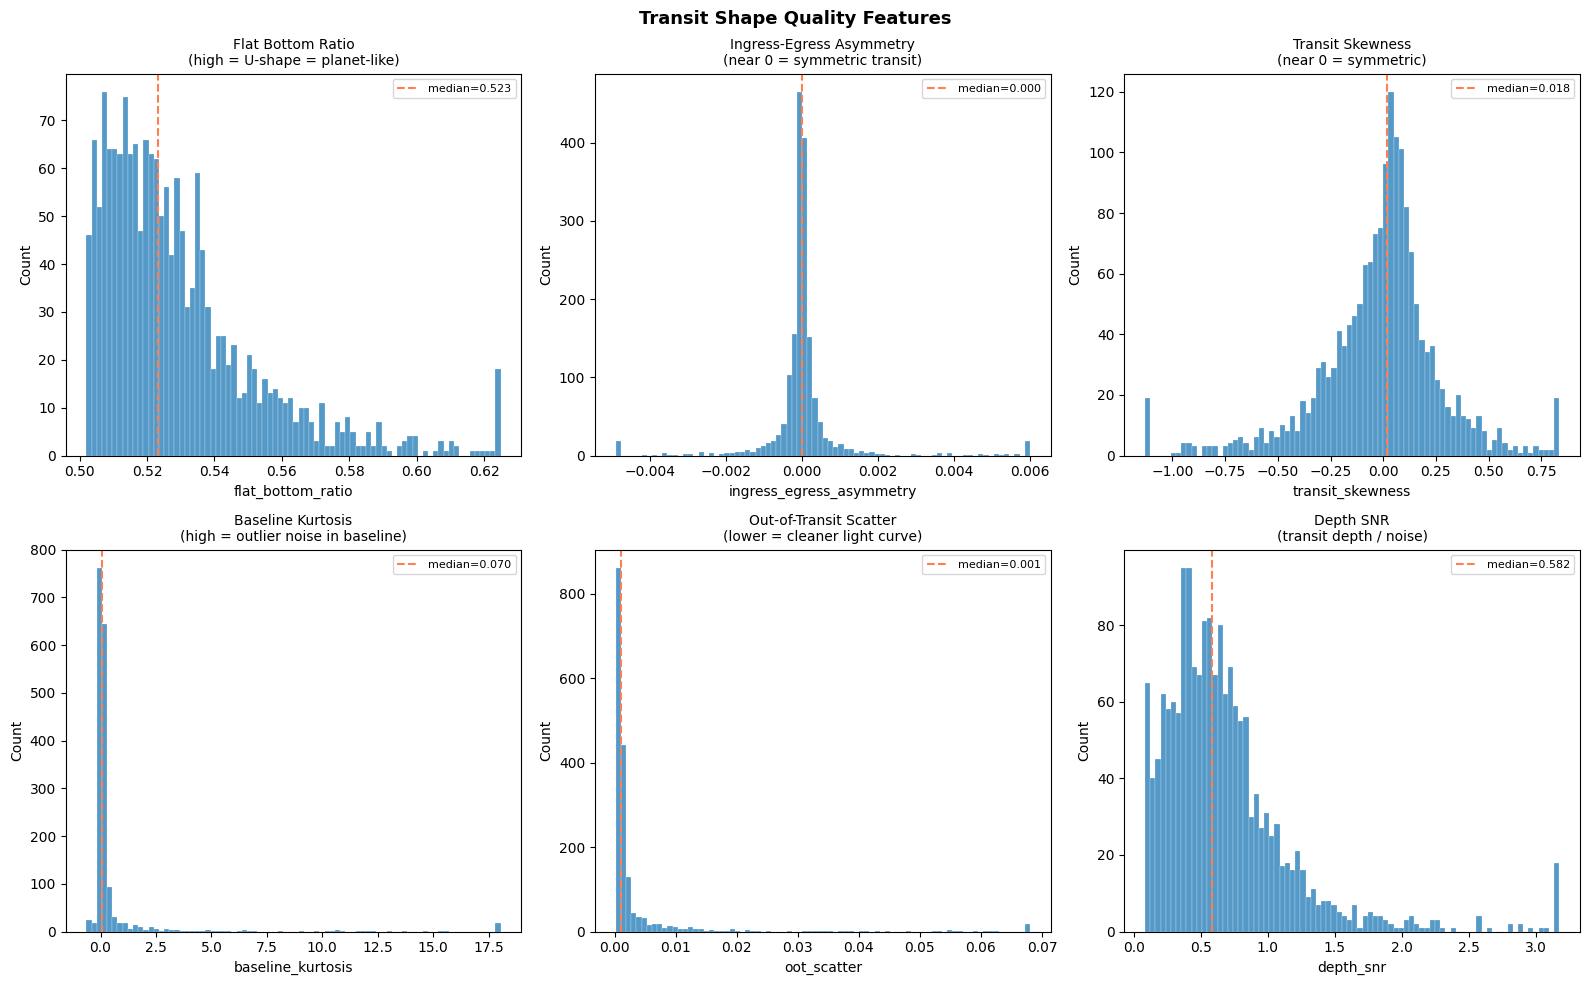

In [56]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

shape_features = {
    'flat_bottom_ratio':        'Flat Bottom Ratio\n(high = U-shape = planet-like)',
    'ingress_egress_asymmetry': 'Ingress-Egress Asymmetry\n(near 0 = symmetric transit)',
    'transit_skewness':         'Transit Skewness\n(near 0 = symmetric)',
    'baseline_kurtosis':        'Baseline Kurtosis\n(high = outlier noise in baseline)',
    'oot_scatter':              'Out-of-Transit Scatter\n(lower = cleaner light curve)',
    'depth_snr':                'Depth SNR\n(transit depth / noise)',
}

for ax, (col, title) in zip(axes.flatten(), shape_features.items()):
    vals = df_real[col].dropna().values
    p1, p99 = np.nanpercentile(vals, 1), np.nanpercentile(vals, 99)
    vals_c  = np.clip(vals, p1, p99)
    ax.hist(vals_c, bins=80, color='#2980B9', alpha=0.8,
            edgecolor='white', lw=0.2)
    ax.axvline(np.nanmedian(vals), color='coral', lw=1.5, linestyle='--',
               label=f'median={np.nanmedian(vals):.3f}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Transit Shape Quality Features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('final_outputs/TransitQuality', dpi=150, bbox_inches='tight')

plt.show()


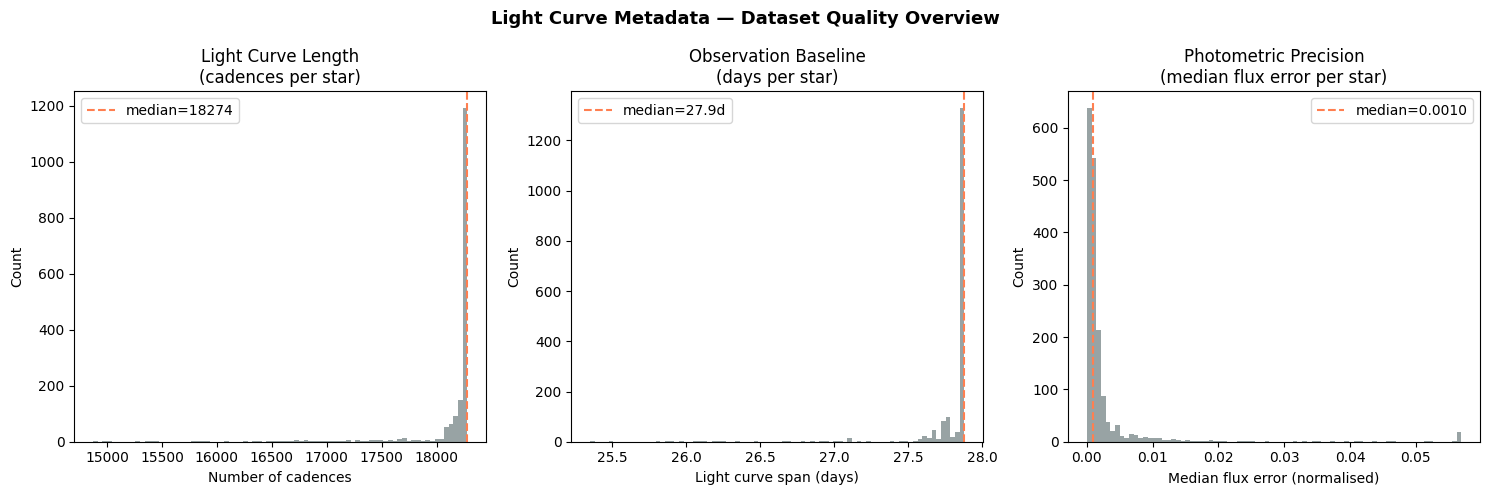

Median cadences  : 18274
Median span      : 27.9 days
Median flux err  : 0.00096
Stars with span < 20d : 0 (0.0%)


In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Number of cadences
nc = df_real['n_cadences'].values
axes[0].hist(nc, bins=80, color='#7F8C8D', alpha=0.8)
axes[0].axvline(np.median(nc), color='coral', lw=1.5, linestyle='--',
                label=f'median={np.median(nc):.0f}')
axes[0].set_xlabel('Number of cadences')
axes[0].set_ylabel('Count')
axes[0].set_title('Light Curve Length\n(cadences per star)')
axes[0].legend()

# LC span
span = df_real['lc_span_days'].values
axes[1].hist(span, bins=80, color='#7F8C8D', alpha=0.8)
axes[1].axvline(np.median(span), color='coral', lw=1.5, linestyle='--',
                label=f'median={np.median(span):.1f}d')
axes[1].set_xlabel('Light curve span (days)')
axes[1].set_ylabel('Count')
axes[1].set_title('Observation Baseline\n(days per star)')
axes[1].legend()

# Median flux error
mfe = df_real['median_flux_err'].values
mfe_c = np.clip(mfe, 0, np.nanpercentile(mfe, 99))
axes[2].hist(mfe_c, bins=80, color='#7F8C8D', alpha=0.8)
axes[2].axvline(np.median(mfe), color='coral', lw=1.5, linestyle='--',
                label=f'median={np.median(mfe):.4f}')
axes[2].set_xlabel('Median flux error (normalised)')
axes[2].set_ylabel('Count')
axes[2].set_title('Photometric Precision\n(median flux error per star)')
axes[2].legend()

plt.suptitle('Light Curve Metadata — Dataset Quality Overview',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('final_outputs/LightCurveMetaData', dpi=150, bbox_inches='tight')

plt.show()

print(f"Median cadences  : {np.median(nc):.0f}")
print(f"Median span      : {np.median(span):.1f} days")
print(f"Median flux err  : {np.median(mfe):.5f}")
print(f"Stars with span < 20d : {(span < 20).sum()} ({(span<20).mean()*100:.1f}%)")

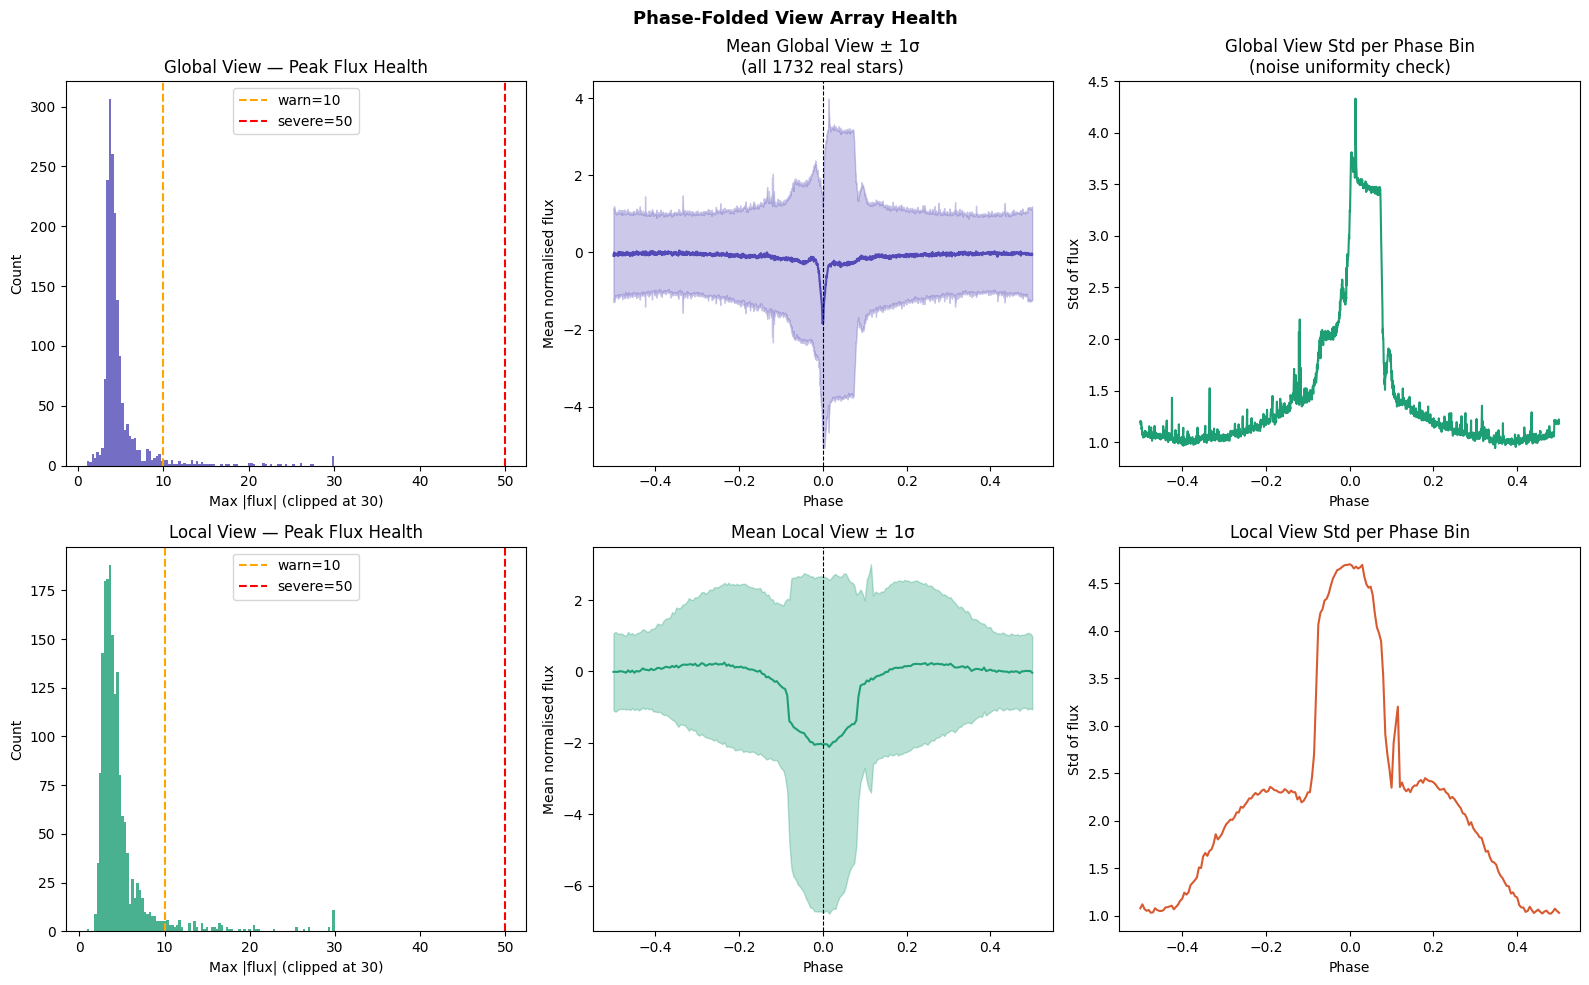

Global view outliers (peak > 10): 76 (4.4%)
Local view outliers  (peak > 10): 88 (5.1%)


In [38]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Peak absolute flux per sample
peak_flux = np.abs(gv_real).max(axis=1)
axes[0,0].hist(np.clip(peak_flux, 0, 30), bins=100,
               color='#534AB7', alpha=0.8)
axes[0,0].axvline(10, color='orange', lw=1.5, linestyle='--', label='warn=10')
axes[0,0].axvline(50, color='red',    lw=1.5, linestyle='--', label='severe=50')
axes[0,0].set_xlabel('Max |flux| (clipped at 30)')
axes[0,0].set_ylabel('Count')
axes[0,0].set_title('Global View — Peak Flux Health')
axes[0,0].legend()

# Mean flux per phase bin (average light curve)
mean_gv = np.nanmean(gv_real, axis=0)
std_gv  = np.nanstd(gv_real, axis=0)
phase   = np.linspace(-0.5, 0.5, gv_real.shape[1])
axes[0,1].fill_between(phase, mean_gv - std_gv, mean_gv + std_gv,
                        alpha=0.3, color='#534AB7')
axes[0,1].plot(phase, mean_gv, color='#534AB7', lw=1.5)
axes[0,1].axvline(0, color='black', lw=0.8, linestyle='--')
axes[0,1].set_xlabel('Phase')
axes[0,1].set_ylabel('Mean normalised flux')
axes[0,1].set_title('Mean Global View ± 1σ\n(all 1732 real stars)')

# Std per phase bin
axes[0,2].plot(phase, std_gv, color='#1D9E75', lw=1.5)
axes[0,2].set_xlabel('Phase')
axes[0,2].set_ylabel('Std of flux')
axes[0,2].set_title('Global View Std per Phase Bin\n(noise uniformity check)')

# Local view equivalents
peak_lv = np.abs(lv_real).max(axis=1)
axes[1,0].hist(np.clip(peak_lv, 0, 30), bins=100,
               color='#1D9E75', alpha=0.8)
axes[1,0].axvline(10, color='orange', lw=1.5, linestyle='--', label='warn=10')
axes[1,0].axvline(50, color='red',    lw=1.5, linestyle='--', label='severe=50')
axes[1,0].set_xlabel('Max |flux| (clipped at 30)')
axes[1,0].set_ylabel('Count')
axes[1,0].set_title('Local View — Peak Flux Health')
axes[1,0].legend()

mean_lv = np.nanmean(lv_real, axis=0)
std_lv  = np.nanstd(lv_real, axis=0)
phase_l = np.linspace(-0.5, 0.5, lv_real.shape[1])
axes[1,1].fill_between(phase_l, mean_lv - std_lv, mean_lv + std_lv,
                        alpha=0.3, color='#1D9E75')
axes[1,1].plot(phase_l, mean_lv, color='#1D9E75', lw=1.5)
axes[1,1].axvline(0, color='black', lw=0.8, linestyle='--')
axes[1,1].set_xlabel('Phase')
axes[1,1].set_ylabel('Mean normalised flux')
axes[1,1].set_title('Mean Local View ± 1σ')

axes[1,2].plot(phase_l, std_lv, color='#D85A30', lw=1.5)
axes[1,2].set_xlabel('Phase')
axes[1,2].set_ylabel('Std of flux')
axes[1,2].set_title('Local View Std per Phase Bin')

plt.suptitle('Phase-Folded View Array Health',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('final_outputs/GlobalHealth', dpi=150, bbox_inches='tight')

plt.show()

print(f"Global view outliers (peak > 10): {(peak_flux > 10).sum()} "
      f"({(peak_flux > 10).mean()*100:.1f}%)")
print(f"Local view outliers  (peak > 10): {(peak_lv > 10).sum()} "
      f"({(peak_lv > 10).mean()*100:.1f}%)")

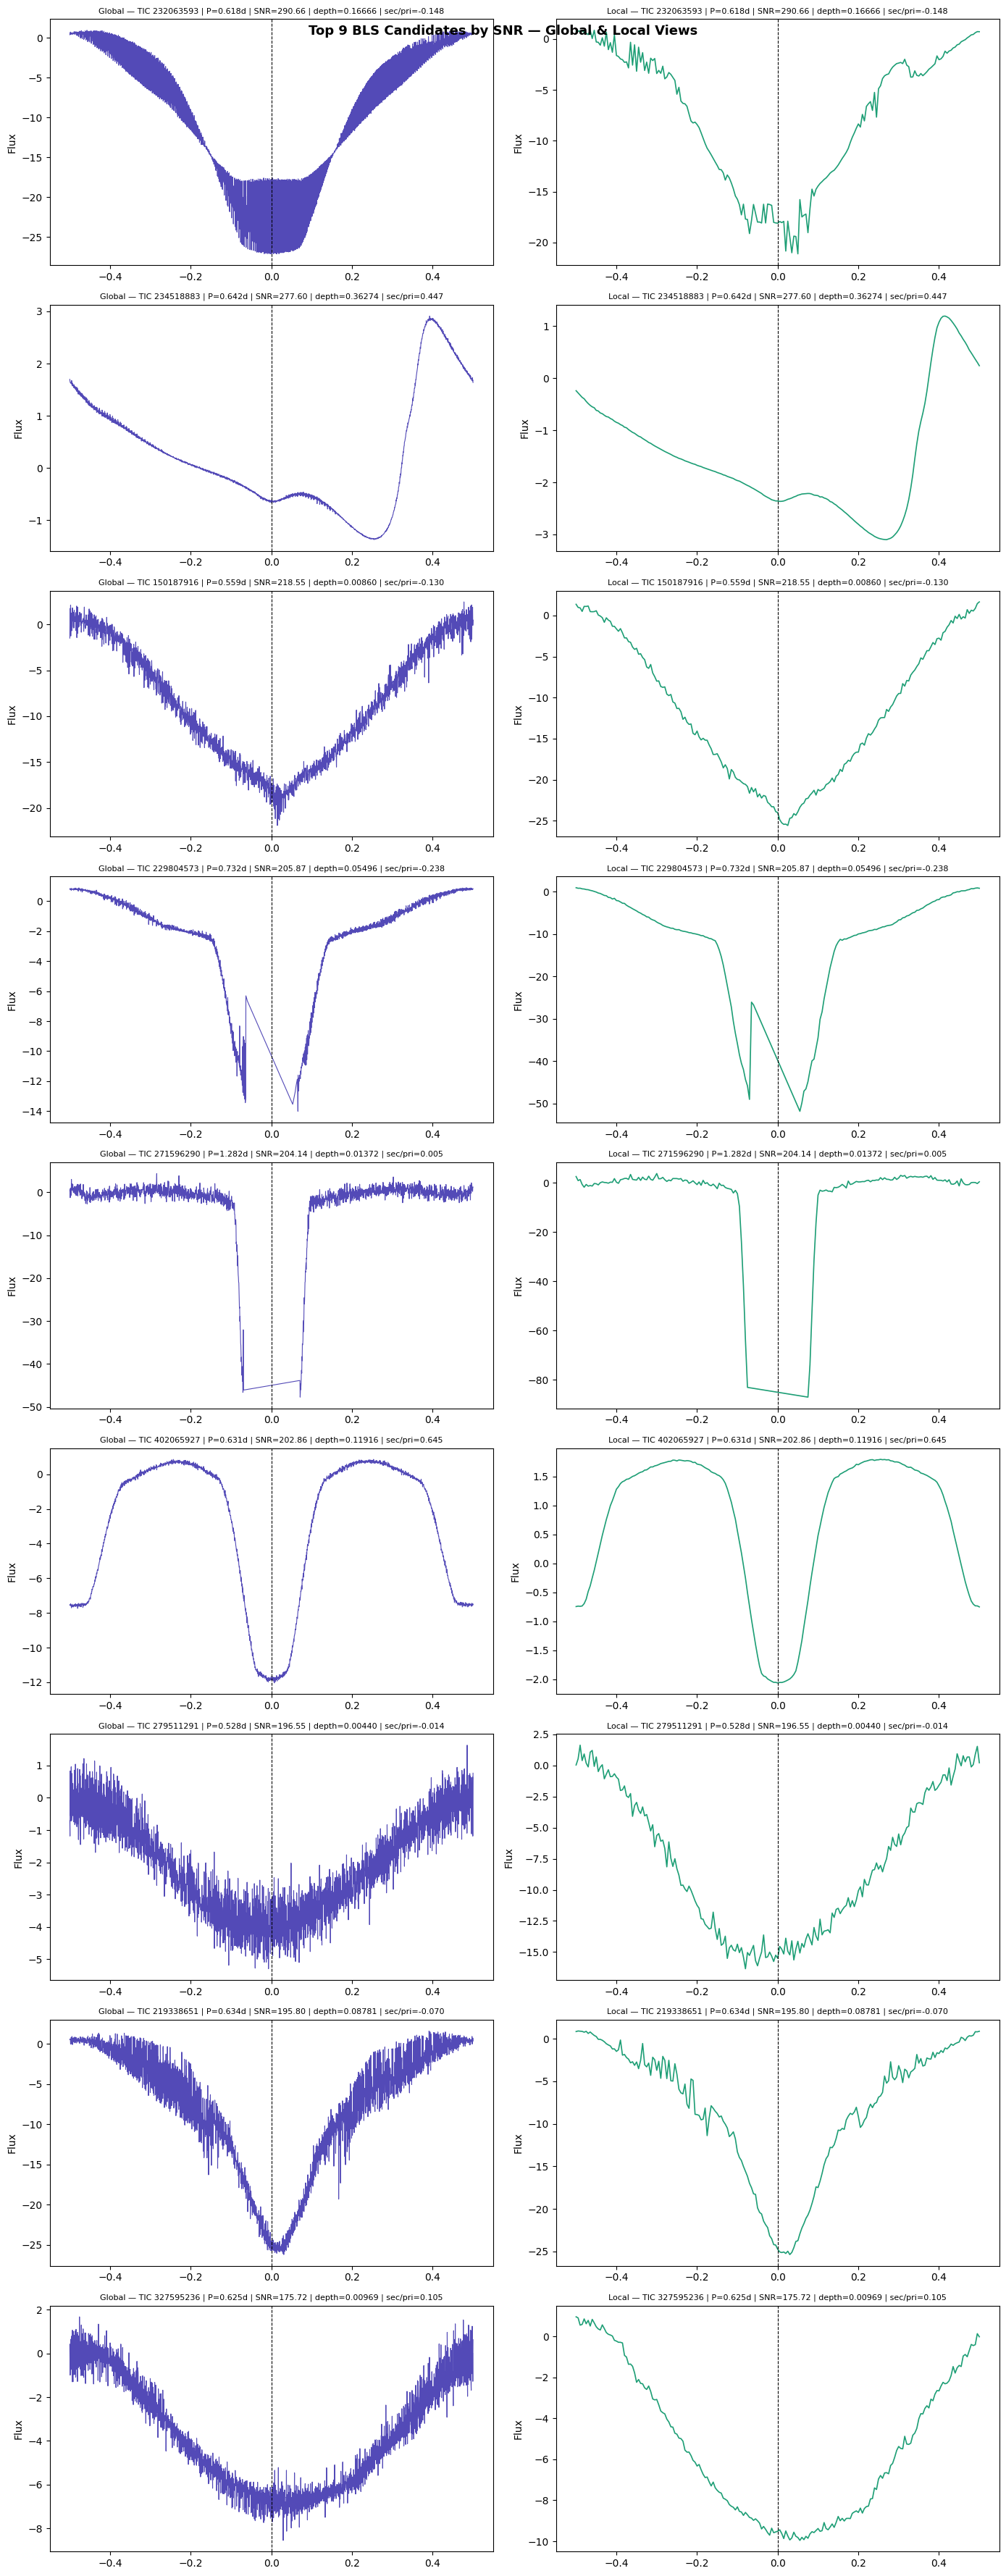


Top 9 candidate summary:
 target_id  bls_period    bls_snr  bls_depth  secondary_primary_ratio  odd_even_depth_ratio  flat_bottom_ratio  n_transits
 232063593    0.617559 290.657398   0.166660                -0.147959              0.657968           0.712873   45.143894
 234518883    0.642187 277.599082   0.362742                 0.447464              0.111311           0.588053   43.415464
 150187916    0.558948 218.546820   0.008600                -0.129847              2.629704           0.644441   49.880510
 229804573    0.732074 205.865208   0.054960                -0.237798              0.020105           0.577731   38.083904
 271596290    1.282269 204.143222   0.013716                 0.004752              0.653052           0.579044   21.742779
 402065927    0.631397 202.858331   0.119165                 0.645402              0.294036           0.637591   44.156656
 279511291    0.528481 196.554553   0.004398                -0.014076              0.142587           0.581541   

In [39]:
# Sort by BLS SNR and show top 9
top_idx = df_real.nlargest(9, 'bls_snr').index
fig, axes = plt.subplots(9, 2, figsize=(14, 36))

for row_i, idx in enumerate(top_idx):
    row   = df_real.loc[idx]
    gv    = gv_real[df_real.index.get_loc(idx)]
    lv    = lv_real[df_real.index.get_loc(idx)]
    phase = np.linspace(-0.5, 0.5, len(gv))
    phl   = np.linspace(-0.5, 0.5, len(lv))

    title = (f"TIC {row['target_id']} | "
             f"P={row['bls_period']:.3f}d | "
             f"SNR={row['bls_snr']:.2f} | "
             f"depth={row['bls_depth']:.5f} | "
             f"sec/pri={row['secondary_primary_ratio']:.3f}")

    axes[row_i, 0].plot(phase, gv, lw=0.8, color='#534AB7')
    axes[row_i, 0].axvline(0, color='black', lw=0.8, linestyle='--')
    axes[row_i, 0].set_ylabel('Flux')
    axes[row_i, 0].set_title(f'Global — {title}', fontsize=8)

    axes[row_i, 1].plot(phl, lv, lw=1.2, color='#1D9E75')
    axes[row_i, 1].axvline(0, color='black', lw=0.8, linestyle='--')
    axes[row_i, 1].set_ylabel('Flux')
    axes[row_i, 1].set_title(f'Local — {title}', fontsize=8)

plt.suptitle('Top 9 BLS Candidates by SNR — Global & Local Views',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('final_outputs/BLSCandidates', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 9 candidate summary:")
print(df_real.nlargest(9, 'bls_snr')[
    ['target_id', 'bls_period', 'bls_snr', 'bls_depth',
     'secondary_primary_ratio', 'odd_even_depth_ratio',
     'flat_bottom_ratio', 'n_transits']
].to_string(index=False))

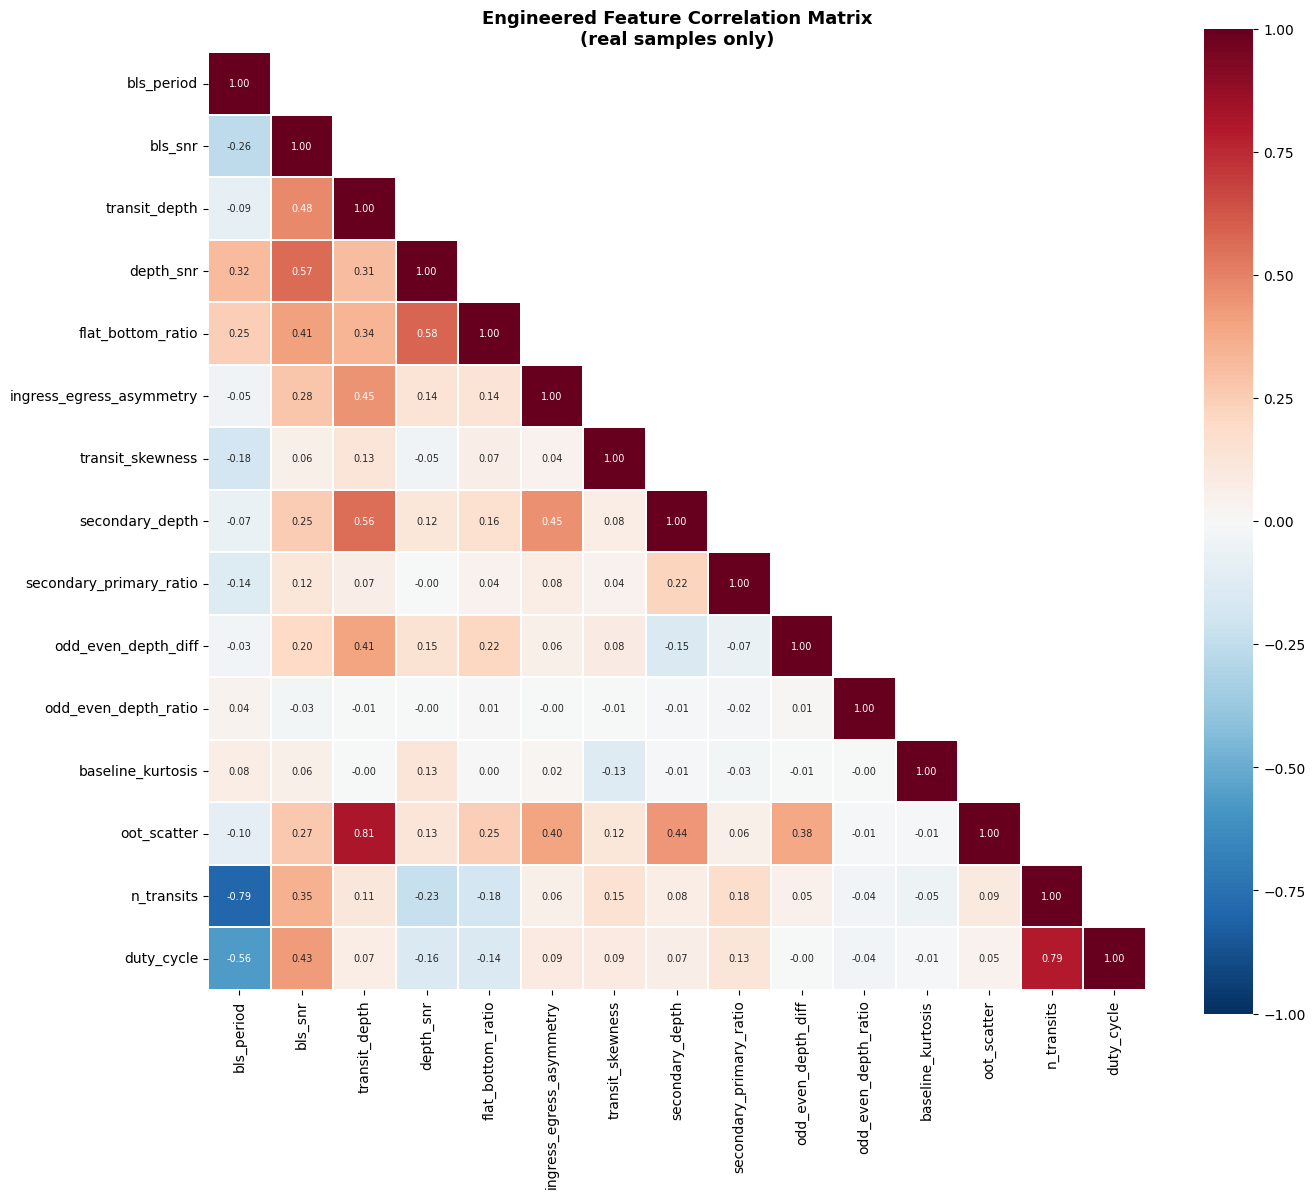

High correlations (|r| > 0.5):
  bls_period                     ↔ n_transits                      r=-0.792
  bls_period                     ↔ duty_cycle                      r=-0.563
  bls_snr                        ↔ depth_snr                       r=0.566
  transit_depth                  ↔ secondary_depth                 r=0.558
  transit_depth                  ↔ oot_scatter                     r=0.814
  depth_snr                      ↔ flat_bottom_ratio               r=0.580
  n_transits                     ↔ duty_cycle                      r=0.792


In [40]:
corr_cols = [
    'bls_period', 'bls_snr', 'transit_depth', 'depth_snr',
    'flat_bottom_ratio', 'ingress_egress_asymmetry', 'transit_skewness',
    'secondary_depth', 'secondary_primary_ratio',
    'odd_even_depth_diff', 'odd_even_depth_ratio',
    'baseline_kurtosis', 'oot_scatter', 'n_transits', 'duty_cycle'
]

corr_df = df_real[corr_cols].dropna()
corr_mat = corr_df.corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
sns.heatmap(
    corr_mat, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, ax=ax, annot_kws={'size': 7},
    linewidths=0.3
)
ax.set_title('Engineered Feature Correlation Matrix\n(real samples only)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('final_outputs/EngCorrMx', dpi=150, bbox_inches='tight')
plt.show()

# Print high correlations
print("High correlations (|r| > 0.5):")
for i in range(len(corr_mat.columns)):
    for j in range(i+1, len(corr_mat.columns)):
        r = corr_mat.iloc[i, j]
        if abs(r) > 0.5:
            print(f"  {corr_mat.columns[i]:30s} ↔ "
                  f"{corr_mat.columns[j]:30s}  r={r:.3f}")

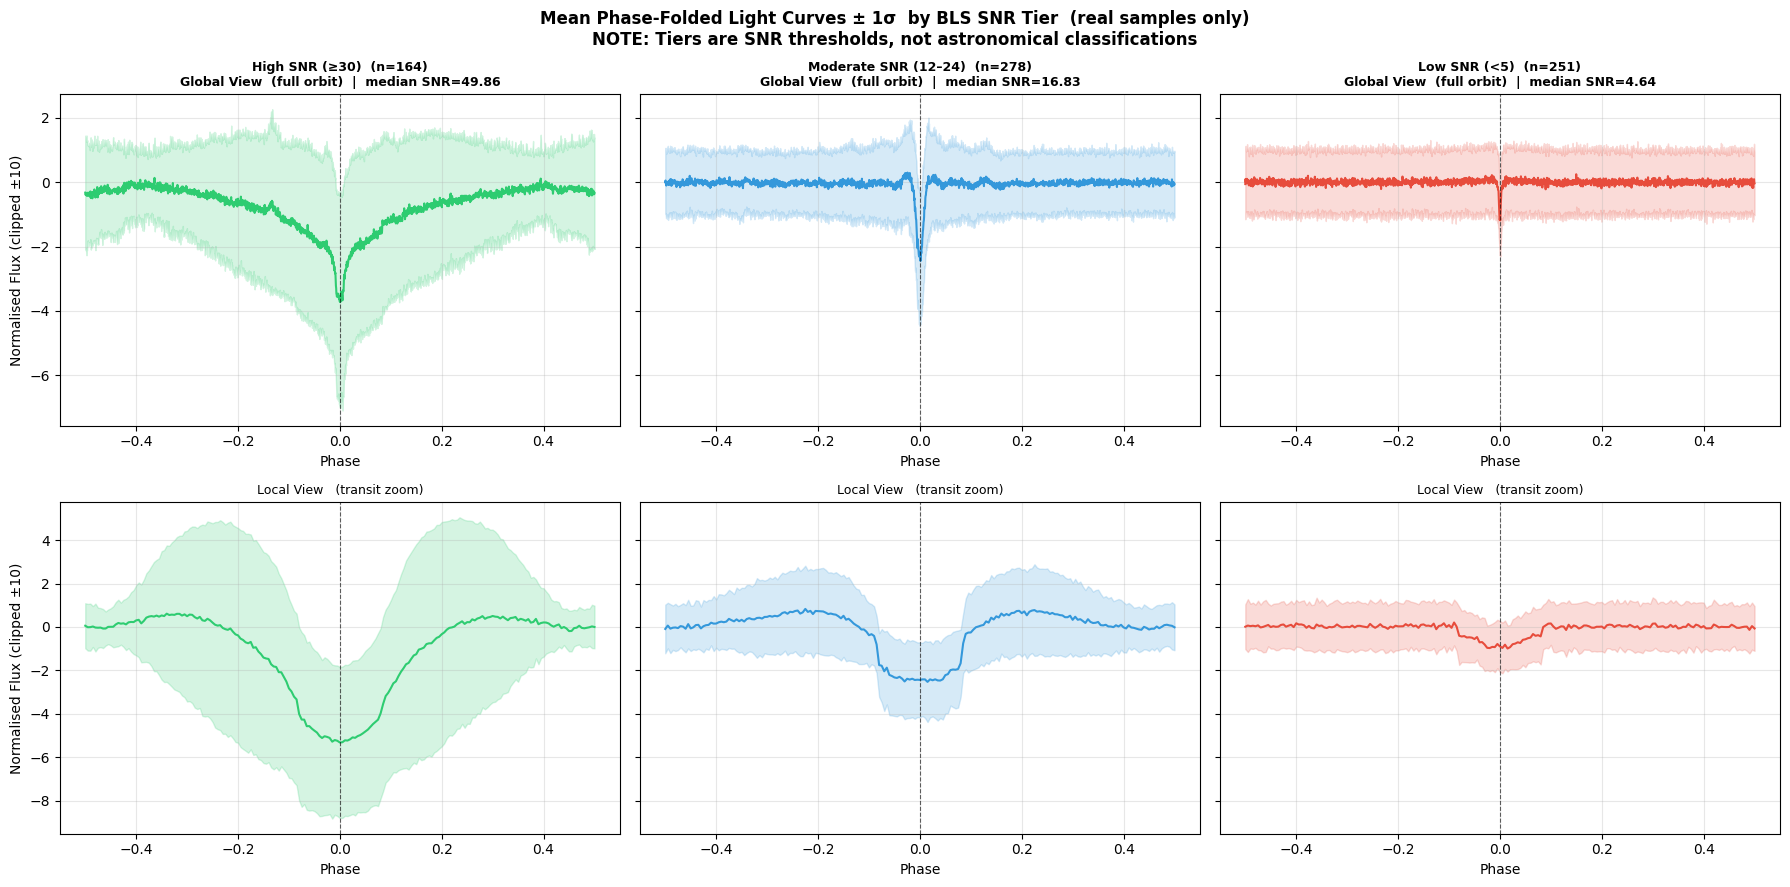

SNR tier breakdown:
  High SNR (≥30)        :   164 stars  (9.5%)
  Moderate SNR (12–24)  :   278 stars  (16.1%)
  Low SNR (<5)          :   251 stars  (14.5%)


In [50]:
# ── Phase Folded Light Curve — Science Dataset (SNR-stratified) ───────────

phase_g = np.linspace(-0.5, 0.5, 2000)
phase_l = np.linspace(-0.5, 0.5, 201)

CLIP = 10.0
gv_clipped = np.clip(gv_real, -CLIP, CLIP)
lv_clipped = np.clip(lv_real, -CLIP, CLIP)

# SNR tiers — physically motivated thresholds
# These replace the label-based stratification from the TOI EDA
SNR_TIERS = {
    'High SNR (≥30)':     df_real['bls_snr'] >= 30,
    'Moderate SNR (12–24)': (df_real['bls_snr'] >= 12) & (df_real['bls_snr'] < 24),
    'Low SNR (<5)':       df_real['bls_snr'] < 5,
}

TIER_COLORS = {
    'High SNR (≥30)':      '#2ecc71',
    'Moderate SNR (12–24)': '#3498db',
    'Low SNR (<5)':       '#e74c3c',
}

fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharey='row')

for col, (tier_name, tier_mask) in enumerate(SNR_TIERS.items()):
    mask   = tier_mask.values
    color  = TIER_COLORS[tier_name]
    n      = mask.sum()

    for row_idx, (arr, phase, view_name) in enumerate([
        (gv_clipped, phase_g, 'Global View  (full orbit)'),
        (lv_clipped, phase_l, 'Local View   (transit zoom)'),
    ]):
        ax     = axes[row_idx, col]
        subset = arr[mask]

        if len(subset) == 0:
            ax.text(0.5, 0.5, 'No samples', transform=ax.transAxes,
                    ha='center', va='center', fontsize=10, color='gray')
            ax.set_title(f'{tier_name}  (n=0)\n{view_name}',
                         fontweight='bold', fontsize=9)
            continue

        mean = np.nanmean(subset, axis=0)
        std  = np.nanstd(subset,  axis=0)

        ax.plot(phase, mean, color=color, linewidth=1.5)
        ax.fill_between(phase, mean - std, mean + std,
                        color=color, alpha=0.2)
        ax.axvline(0, color='k', linestyle='--', linewidth=0.8, alpha=0.6)
        ax.grid(alpha=0.3)

        if row_idx == 0:
            snr_med = df_real.loc[mask, 'bls_snr'].median()
            ax.set_title(f'{tier_name}  (n={n})\n'
                         f'{view_name}  |  median SNR={snr_med:.2f}',
                         fontweight='bold', fontsize=9)
        else:
            ax.set_title(view_name, fontsize=9)

        ax.set_xlabel('Phase')

axes[0, 0].set_ylabel('Normalised Flux (clipped ±10)')
axes[1, 0].set_ylabel('Normalised Flux (clipped ±10)')

plt.suptitle(
    'Mean Phase-Folded Light Curves ± 1σ  by BLS SNR Tier  (real samples only)\n'
    'NOTE: Tiers are SNR thresholds, not astronomical classifications',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('final_outputs/PhaseFolded_SNR_Tiers.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────
print("SNR tier breakdown:")
for name, mask in SNR_TIERS.items():
    n = mask.sum()
    print(f"  {name:<22}: {n:>5} stars  ({n/len(df_real)*100:.1f}%)")

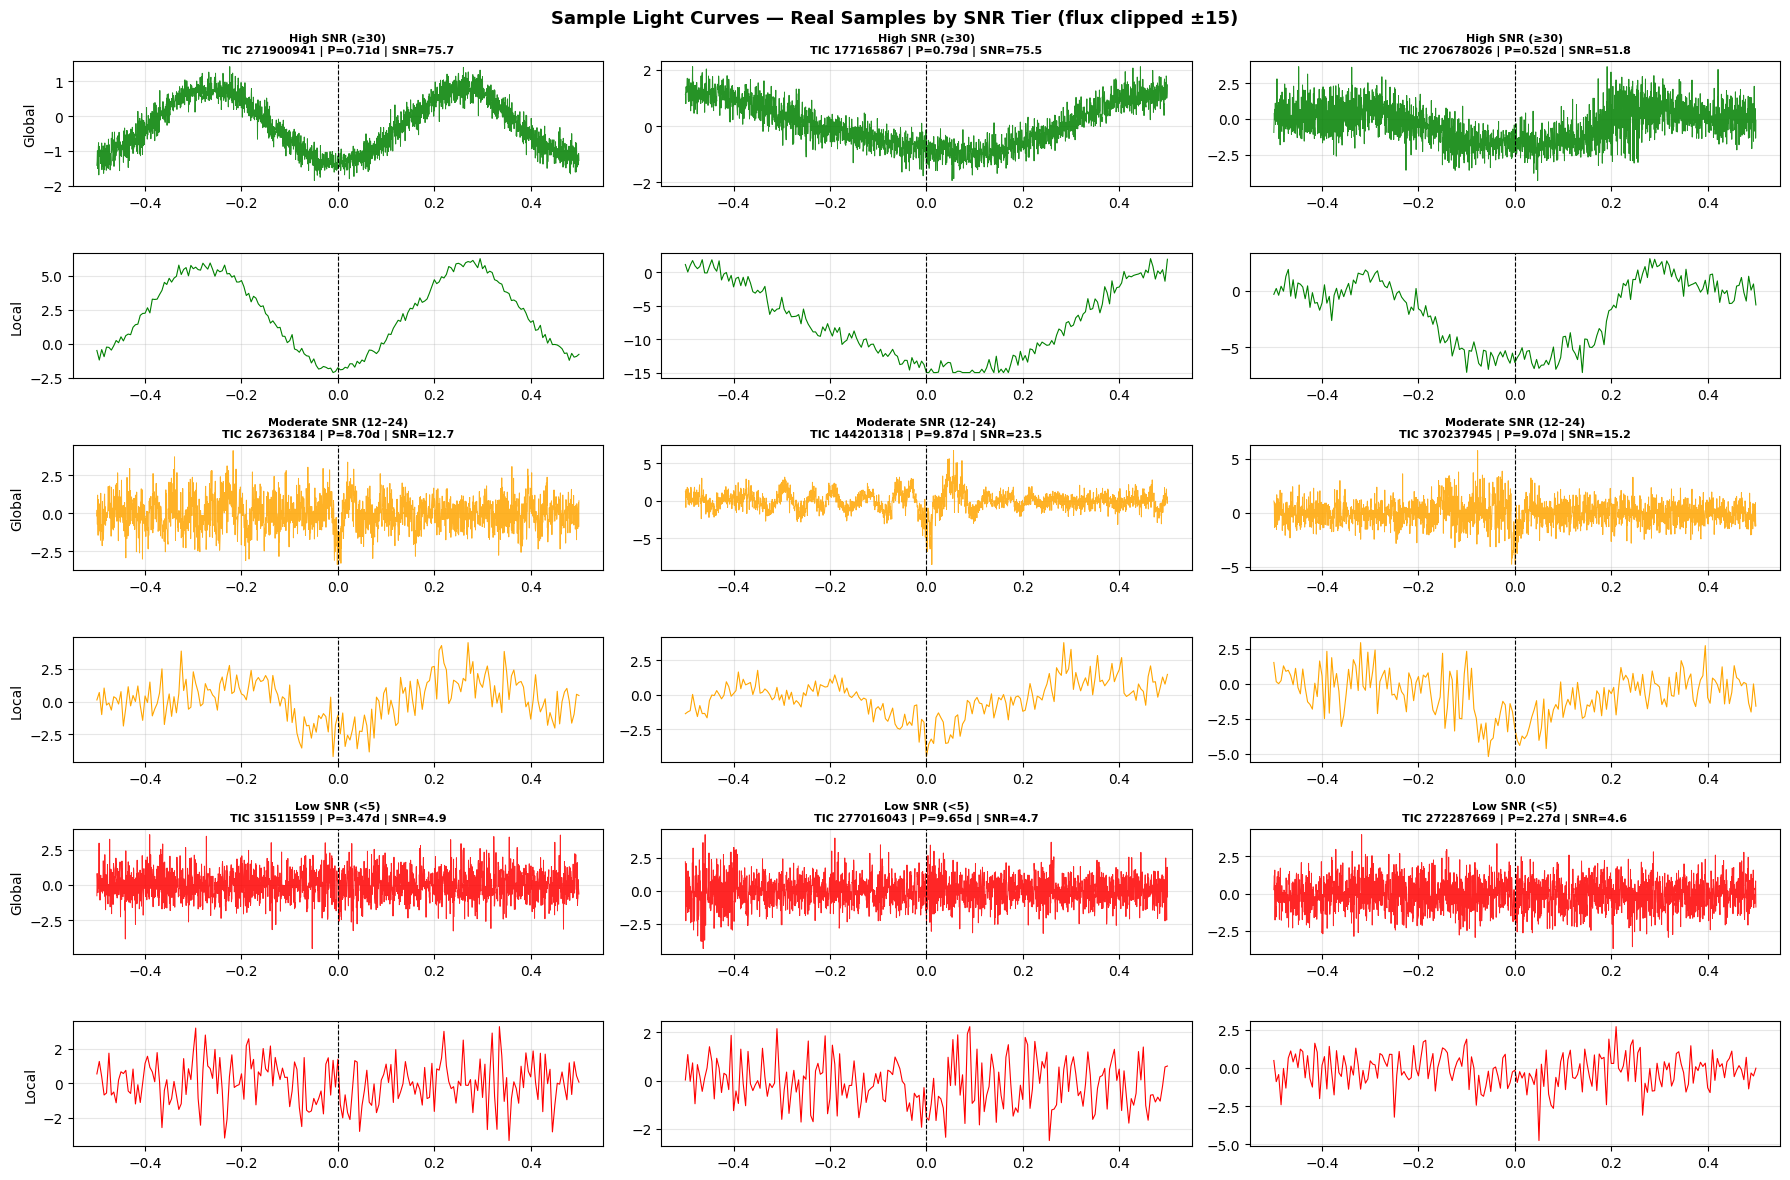

In [53]:
# --- Sample Real Light Curves by SNR Tier ---
N_SAMPLES = 3
rng = np.random.default_rng(42)

SNR_TIERS = {
    'High SNR (≥30)':       df_real['bls_snr'] >= 30,
    'Moderate SNR (12–24)': (df_real['bls_snr'] >= 12) & (df_real['bls_snr'] < 24),
    'Low SNR (<5)':         df_real['bls_snr'] < 5,
}

# Optional colors for each tier
SNR_COLORS = {
    'High SNR (≥30)': 'green',
    'Moderate SNR (12–24)': 'orange',
    'Low SNR (<5)': 'red'
}

fig, axes = plt.subplots(
    len(SNR_TIERS) * 2,
    N_SAMPLES,
    figsize=(18, 12)
)

for row_pair, (tier_name, mask) in enumerate(SNR_TIERS.items()):

    idx_pool = np.where(mask)[0]

    # Handle small sample counts safely
    sample_size = min(N_SAMPLES, len(idx_pool))

    if sample_size == 0:
        continue

    idxs = rng.choice(
        idx_pool,
        size=sample_size,
        replace=False
    )

    for col, idx in enumerate(idxs):

        tid = df_real.iloc[idx]["target_id"]
        per = df_real.iloc[idx]["fold_period"]
        snr = df_real.iloc[idx]["bls_snr"]

        color = SNR_COLORS[tier_name]

        ax_g = axes[row_pair*2, col]
        ax_l = axes[row_pair*2+1, col]

        # Global view
        ax_g.plot(
            phase_g,
            np.clip(gv_real[idx], -15, 15),
            color=color,
            linewidth=0.7,
            alpha=0.85
        )

        ax_g.axvline(
            0,
            color="k",
            linestyle="--",
            linewidth=0.8
        )

        ax_g.set_title(
            f"{tier_name}\n"
            f"TIC {int(tid)} | "
            f"P={per:.2f}d | "
            f"SNR={snr:.1f}",
            fontsize=8,
            fontweight="bold"
        )

        ax_g.set_ylabel("Global" if col == 0 else "")
        ax_g.grid(alpha=0.3)

        # Local view
        ax_l.plot(
            phase_l,
            np.clip(lv_real[idx], -15, 15),
            color=color,
            linewidth=0.8
        )

        ax_l.axvline(
            0,
            color="k",
            linestyle="--",
            linewidth=0.8
        )

        ax_l.set_ylabel("Local" if col == 0 else "")
        ax_l.grid(alpha=0.3)

plt.suptitle(
    "Sample Light Curves — Real Samples by SNR Tier (flux clipped ±15)",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig(
    "final_outputs/SampleCurve_SNR",
    dpi=150,
    bbox_inches='tight'
)

plt.show()